## Module 1 Homework (2026 cohort)

In this homework, we're going to download financial data from various sources and perform simple calculations and analysis.

### Question 1: [Index] S&P 500 Stocks Added to the Index

**Which year had the highest number of additions (starting from 2020)?**
Using the list of S&P 500 companies from Wikipedia's [S&P 500 companies page](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies), download the data including the year each company was added to the index.

Hint: you can use [pandas.read_html](https://pandas.pydata.org/docs/reference/api/pandas.read_html.html) to scrape the data into a DataFrame. You may need to add headers to make it work:

```python
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Fetch the HTML content with headers
response = requests.get(url, headers=headers)
```

Steps:
1. Create a DataFrame with company tickers, names, and the year they were added.
2. Extract the year from the addition date and calculate the number of stocks added each year.
3. Which (full) year had the highest number of additions, starting from 2020? 

▎ Note: When stocks are added to the S&P 500, they usually experience a price bump as investors and index funds buy shares following the announcement.

▎ Context: 
> "Following the announcement, all four new entrants saw their stock prices rise in extended trading on Friday" - recent examples of S&P 500 additions include DASH, WSM, EXE, TKO in 2025 ([Nasdaq article](https://www.nasdaq.com/articles/sp-500-reshuffle-dash-tko-expe-wsm-join-worth-buying)).

*Additional*: How many current S&P 500 stocks have been in the index for more than 20 years? 


### My answer

**1. Download the table and store it with proper dtypes.**

In [1]:
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
import requests

URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
HEADERS = {"User-Agent": "Mozilla/5.0"}

response = requests.get(URL, headers=HEADERS)
response.raise_for_status()

# The page has more than one table, so pick the one with the GICS columns.
table = pd.read_html(StringIO(response.text), match="GICS")[0]

sp500 = pd.DataFrame(
    {
        "ticker": table["Symbol"],
        "company": table["Security"],
        "date_added": pd.to_datetime(table["Date added"]),
    }
)
sp500["year_added"] = sp500["date_added"].dt.year

print(sp500.shape)
sp500.head()

(503, 4)


,ticker,company,date_added,year_added
0,MMM,3M,1957-03-04,1957
1,AOS,A. O. Smith,2017-07-26,2017
2,ABT,Abbott Laboratories,1957-03-04,1957
3,ABBV,AbbVie,2012-12-31,2012
4,ACN,Accenture,2011-07-06,2011


**2. Distribution of additions over the whole history.**

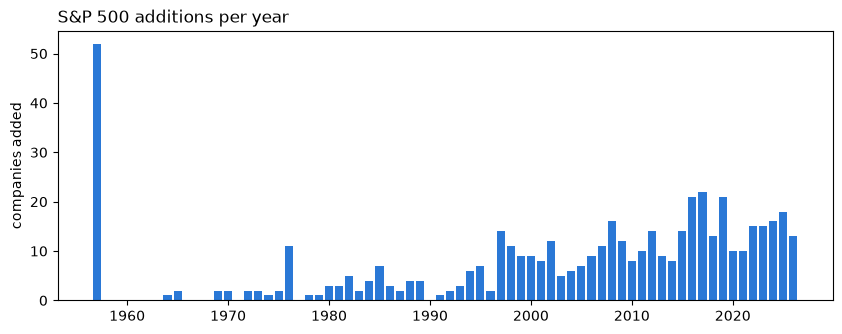

In [2]:
by_year = sp500["year_added"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(by_year.index, by_year.values, color="#2a78d6")
ax.set_title("S&P 500 additions per year", loc="left")
ax.set_ylabel("companies added")
plt.show()

**3. Answer: which full year since 2020 had the most additions?**

In [3]:
# 2026 is left out: the data stops in August, so it is not a full year.
recent = by_year.loc[2020:2025]
print(recent)
print(f"Most additions: {recent.idxmax()} ({recent.max()} companies)")

# Additional: how many have been in the index for more than 20 years?
cutoff = pd.Timestamp.today() - pd.DateOffset(years=20)
print(f"More than 20 years in the index: {(sp500['date_added'] < cutoff).sum()}")

year_added
2020    10
2021    10
2022    15
2023    15
2024    16
2025    18
Name: count, dtype: int64
Most additions: 2025 (18 companies)
More than 20 years in the index: 224


### Question 2. [Macro] Indexes YTD (as of 21 August 2026)

**How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026?**

Using Yahoo Finance World Indices data, compare the year-to-date (YTD) performance (1 January-21 August 2026, use the closing price to calculate the growth) of major stock market indexes for the following countries:
* United States - S&P 500 (^GSPC)
* China - Shanghai Composite (000001.SS)
* Hong Kong - HANG SENG INDEX (^HSI)	
* Australia - S&P/ASX 200 (^AXJO)
* India - Nifty 50 (^NSEI)
* Canada - S&P/TSX Composite (^GSPTSE)
* Germany - DAX (^GDAXI)
* United Kingdom - FTSE 100 (^FTSE)
* Japan - Nikkei 225 (^N225)
* Mexico - IPC Mexico (^MXX)
* Brazil - Ibovespa (^BVSP)

*Hint*: use ```start_date='2026-01-01'``` and ```end_date='2026-08-21'``` parameters when downloading daily data in yfinance

Context: 
> [Global Valuations: Who's Cheap, Who's Not?](https://simplywall.st/article/beyond-the-us-global-markets-after-yet-another-tariff-update) article suggests "Other regions may be growing faster than the US and you need to diversify."

Reference: Yahoo Finance World Indices - https://finance.yahoo.com/world-indices/

*Additional*: How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend?
Note: For simplicity, ignore currency conversion effects.

### My answer

**1. YTD returns from 1 January to 21 August 2026.**

In [4]:
import yfinance as yf

INDEXES = {
    "^GSPC": "United States - S&P 500",
    "000001.SS": "China - Shanghai Composite",
    "^HSI": "Hong Kong - Hang Seng",
    "^AXJO": "Australia - S&P/ASX 200",
    "^NSEI": "India - Nifty 50",
    "^GSPTSE": "Canada - S&P/TSX Composite",
    "^GDAXI": "Germany - DAX",
    "^FTSE": "United Kingdom - FTSE 100",
    "^N225": "Japan - Nikkei 225",
    "^MXX": "Mexico - IPC Mexico",
    "^BVSP": "Brazil - Ibovespa",
}

close = yf.download(
    list(INDEXES), start="2026-01-01", end="2026-08-22", auto_adjust=True, progress=False
)["Close"]

ytd = (
    (close.ffill().iloc[-1] / close.bfill().iloc[0] - 1)
    .mul(100)
    .rename(index=INDEXES)
    .rename("ytd_return_%")
    .sort_values(ascending=False)
    .round(2)
)

sp500_ytd = ytd["United States - S&P 500"]
print(ytd)
print(f"S&P 500: {sp500_ytd}%")
print(f"Indexes with a better YTD return: {(ytd > sp500_ytd).sum()}")

Ticker
Japan - Nikkei 225            27.36
Canada - S&P/TSX Composite    14.86
United States - S&P 500       11.90
United Kingdom - FTSE 100      8.70
Brazil - Ibovespa              6.54
Germany - DAX                  6.51
Australia - S&P/ASX 200        3.79
Mexico - IPC Mexico            2.48
Hong Kong - Hang Seng         -1.25
China - Shanghai Composite    -2.94
India - Nifty 50              -7.25
Name: ytd_return_%, dtype: float64
S&P 500: 11.9%
Indexes with a better YTD return: 2


**2. Additional: the same comparison over 3, 5 and 10 years.**

In [5]:
PERIODS = {"3 years": "2023-08-21", "5 years": "2021-08-21", "10 years": "2016-08-21"}

history = yf.download(
    list(INDEXES), start="2016-08-01", end="2026-08-22", auto_adjust=True, progress=False
)["Close"].ffill()

returns = (
    pd.DataFrame(
        {
            label: history.loc[start:].iloc[-1] / history.loc[start:].iloc[0] - 1
            for label, start in PERIODS.items()
        }
    )
    .mul(100)
    .rename(index=INDEXES)
    .round(2)
    .sort_values("10 years", ascending=False)
)

print(returns)
print(f"Better than the S&P 500:")
print((returns > returns.loc["United States - S&P 500"]).sum())

                            3 years  5 years  10 years
Ticker                                                
Japan - Nikkei 225           109.14   140.11    297.73
United States - S&P 500       74.43    71.32    251.61
Brazil - Ibovespa             49.47    45.59    196.00
India - Nifty 50              25.05    47.01    181.05
Germany - DAX                 67.51    64.87    149.05
Canada - S&P/TSX Composite    85.09    78.83    148.30
Australia - S&P/ASX 200       27.31    20.95     64.26
United Kingdom - FTSE 100     49.03    52.15     58.40
Mexico - IPC Mexico           23.76    26.27     36.10
China - Shanghai Composite    26.26    12.31     26.59
Hong Kong - Hang Seng         47.59     3.58     13.09
Better than the S&P 500:
3 years     2
5 years     2
10 years    1
dtype: int64


### Question 3. [Index] S&P 500 Market Corrections Analysis


**Calculate the median drawdown (in %) of significant market corrections in the S&P 500 index.**

For this task, define a correction as an event when a stock index goes down by **at least 5%** from the most recent all-time high.

Steps:
1. Download S&P 500 historical data (period from 1950 to present) using yfinance (daily stats)
2. Identify all-time high closing price points (where price exceeds all previous days' prices)
3. For each pair of consecutive all-time highs, find the minimum price in between
4. Calculate drawdown percentages: (high - low) / high × 100
5. Filter for corrections with at least 5% drawdown
6. Calculate the duration in days for each correction period
7. Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns

*Context:* 
> * Investors often wonder about the typical length of market corrections when deciding "when to buy the dip" ([Reddit discussion](https://www.reddit.com/r/investing/comments/1jrqnte/when_are_you_buying_the_dip/?rdt=64135)).

> * [A Wealth of Common Sense - How Often Should You Expect a Stock Market Correction?](https://awealthofcommonsense.com/2022/01/how-often-should-you-expect-a-stock-market-correction/)

*Hint (use this data to compare with your results)*: Here is the list of top 10 largest corrections by drawdown:
* 2007-10-09 to 2009-03-09: 56.8% drawdown over 517 days
* 2000-03-24 to 2002-10-09: 49.1% drawdown over 929 days
* 1973-01-11 to 1974-10-03: 48.2% drawdown over 630 days
* 1968-11-29 to 1970-05-26: 36.1% drawdown over 543 days
* 2020-02-19 to 2020-03-23: 33.9% drawdown over 33 days
* 1987-08-25 to 1987-12-04: 33.5% drawdown over 101 days
* 1961-12-12 to 1962-06-26: 28.0% drawdown over 196 days
* 1980-11-28 to 1982-08-12: 27.1% drawdown over 622 days
* 2022-01-03 to 2022-10-12: 25.4% drawdown over 282 days
* 1966-02-09 to 1966-10-07: 22.2% drawdown over 240 days

### My answer

**1. All-time highs, the trough that follows each one, and the drawdown between them.**

In [6]:
close = yf.download("^GSPC", start="1950-01-01", auto_adjust=True, progress=False)["Close"]["^GSPC"]

is_all_time_high = close == close.cummax()
blocks = close.groupby(is_all_time_high.cumsum())

drawdowns = pd.DataFrame(
    {
        "peak_date": blocks.apply(lambda prices: prices.index[0]),
        "peak": blocks.first(),
        "trough_date": blocks.idxmin(),
        "trough": blocks.min(),
    }
)
drawdowns["drawdown_%"] = (1 - drawdowns["trough"] / drawdowns["peak"]) * 100
drawdowns["duration_days"] = (drawdowns["trough_date"] - drawdowns["peak_date"]).dt.days

corrections = drawdowns[drawdowns["drawdown_%"] >= 5].reset_index(drop=True)

print(f"{len(corrections)} corrections of at least 5% since 1950")
corrections.nlargest(10, "drawdown_%")[["peak_date", "trough_date", "drawdown_%", "duration_days"]]

74 corrections of at least 5% since 1950


,peak_date,trough_date,drawdown_%,duration_days
56,2007-10-09,2009-03-09,56.775388,517
54,2000-03-24,2002-10-09,49.146948,929
24,1973-01-11,1974-10-03,48.203593,630
22,1968-11-29,1970-05-26,36.061641,543
65,2020-02-19,2020-03-23,33.924960,33
35,1987-08-25,1987-12-04,33.509515,101
15,1961-12-12,1962-06-26,27.973568,196
27,1980-11-28,1982-08-12,27.113582,622
68,2022-01-03,2022-10-12,25.425097,282
18,1966-02-09,1966-10-07,22.177335,240


**2. Percentiles of the drawdowns and their durations.**

In [7]:
print(corrections[["drawdown_%", "duration_days"]].describe(percentiles=[0.25, 0.5, 0.75]).round(1))
print(f"Median drawdown: {corrections['drawdown_%'].median():.1f}%")
print(f"Median duration: {corrections['duration_days'].median():.0f} days")

       drawdown_%  duration_days
count        74.0           74.0
mean         12.5          110.3
std          10.9          175.9
min           5.0            7.0
25%           6.2           22.0
50%           8.0           40.5
75%          14.0           86.2
max          56.8          929.0
Median drawdown: 8.0%
Median duration: 40 days


**3. How the corrections are distributed.**

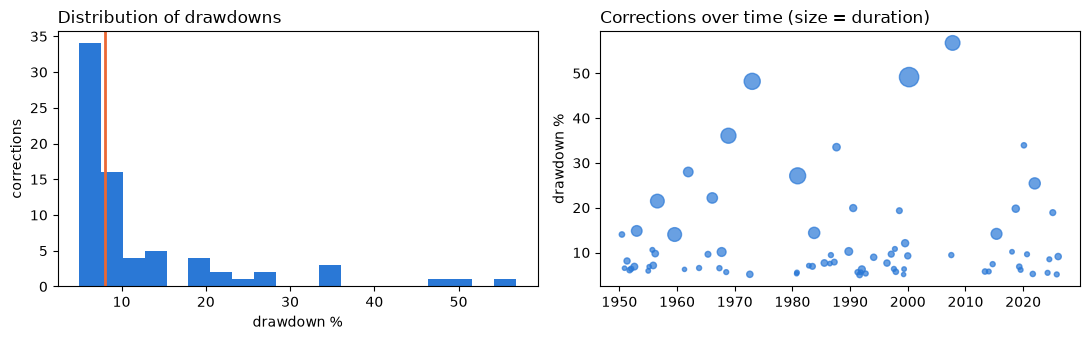

In [8]:
fig, (ax_hist, ax_time) = plt.subplots(1, 2, figsize=(11, 3.5))

ax_hist.hist(corrections["drawdown_%"], bins=20, color="#2a78d6")
ax_hist.axvline(corrections["drawdown_%"].median(), color="#eb6834", linewidth=2)
ax_hist.set_title("Distribution of drawdowns", loc="left")
ax_hist.set_xlabel("drawdown %")
ax_hist.set_ylabel("corrections")

ax_time.scatter(
    corrections["peak_date"], corrections["drawdown_%"], s=corrections["duration_days"] / 5 + 8, color="#2a78d6", alpha=0.7
)
ax_time.set_title("Corrections over time (size = duration)", loc="left")
ax_time.set_ylabel("drawdown %")

fig.tight_layout()
plt.show()

### Question 4.  [Stocks] Earnings Surprise Analysis for Amazon (AMZN)


**Calculate the median 2-day percentage change in stock prices following positive earnings surprise days.**

Steps:
1. Load earnings data for the last few years using the yfinance method get_earnings_dates():
```python
import yfinance as yf

ticker = 'AMZN'
ticker_obj = yf.Ticker(ticker)
result = ticker_obj.get_earnings_dates()
```
You should have 25 entries starting from 2020-10-29. Note: the 1 future earnings date entry will not have Reported EPS  
and Surprise % filled in.

2. Download complete historical price data using yfinance
3. Calculate 2-day percentage changes for all historical dates: for each sequence of 3 consecutive trading days (Day 1, Day 2, Day 3), compute the *return* as Close_Day3 / Close_Day1 - 1. (Assume Day 2 may correspond to the earnings announcement.)
4. Filter for positive earnings surprises and calculate the median 2-day return. Then calculate the correlation between
   the 2-day stock return and the earnings surprise magnitude.

▎ *Hint*: you can generate all correlations at once using pd.corr().

 > **Context:** Earnings announcements, especially when they exceed analyst expectations, can significantly impact stock prices in the short term.

**Reference:** [Yahoo Finance Earnings Calendar](https://finance.yahoo.com/calendar/earnings?symbol=AMZN)

*Additional*: Is there a correlation between the magnitude of the earnings surprise and the stock price reaction? Does the market react differently to earnings surprises during bull vs. bear markets?

### My answer

**1. Earnings dates joined with the 2-day return around each one.**

In [9]:
amzn = yf.Ticker("AMZN")

earnings = amzn.get_earnings_dates(limit=25).dropna(subset=["Surprise(%)"])
close = amzn.history(period="max")["Close"]

two_day_return = (close.shift(-1) / close.shift(1) - 1) * 100
two_day_return.index = two_day_return.index.date

earnings.index = earnings.index.date
earnings["two_day_return_%"] = two_day_return.reindex(earnings.index)

print(earnings.shape)
earnings

(24, 4)


,EPS Estimate,Reported EPS,Surprise(%),two_day_return_%
2026-07-30,1.83,5.75,215.02,19.823514
2026-04-29,1.64,2.78,69.02,2.063914
2026-02-05,1.95,1.95,0.22,-9.730030
2025-10-30,1.56,1.95,25.20,6.044289
2025-07-31,1.32,1.68,27.19,-6.707503
2025-05-01,1.36,1.59,16.77,3.014856
2025-02-06,1.48,1.86,25.29,-2.972437
2024-10-31,1.14,1.43,25.22,2.698074
2024-08-01,1.02,1.26,23.76,-10.204301
2024-04-30,0.83,0.98,17.67,-1.083116


**2. Median 2-day return after a positive surprise, and the correlation.**

In [10]:
positive = earnings[earnings["Surprise(%)"] > 0]

print(f"Positive surprises: {len(positive)}")
print(f"Median 2-day return: {positive['two_day_return_%'].median():.2f}%")
print(positive[["Surprise(%)", "two_day_return_%"]].corr())

Positive surprises: 20
Median 2-day return: 0.35%
                  Surprise(%)  two_day_return_%
Surprise(%)          1.000000          0.330645
two_day_return_%     0.330645          1.000000


**3. Surprise magnitude against the reaction.**

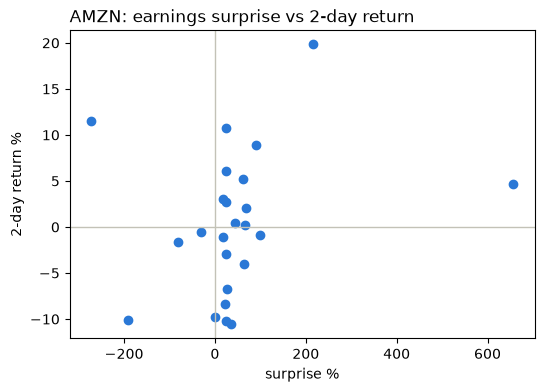

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(earnings["Surprise(%)"], earnings["two_day_return_%"], color="#2a78d6")
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("AMZN: earnings surprise vs 2-day return", loc="left")
ax.set_xlabel("surprise %")
ax.set_ylabel("2-day return %")

plt.show()

### Question 5.  [Exploratory, optional] Brainstorm potential idea for your capstone project

**Free text answer**

Describe the capstone project you would like to pursue, considering your aspirations, ML model predictions, and prior knowledge. Even if you are unsure at this stage, try to generate an idea you would like to explore-such as a specific asset class, country, industry vertical, or investment strategy. Be as specific as possible.

*Example: I want to build a short-term prediction model for the US/India/Brazil stock markets, focusing on the largest stocks over a 30-day investment horizon. I plan to use RSI and MACD technical indicators and news coverage data to generate predictions.*

### My answer

I want to predict **which IBEX 35 stocks go up more than the others** over the next 30
trading days. Not whether the Spanish market goes up - just which stocks inside it do
better than the rest.

- **Market:** Spain, the IBEX 35. I follow it, and it is only 35 stocks.
- **What I predict:** for each stock, on each day, whether its return over the next 30
  trading days is above the middle stock of that day.
- **Data:** daily prices from Yahoo Finance, plus interest rates, EUR/BRL and oil
  (these are the variables I look at in Question 6).
- **Features:** returns over 1, 3 and 12 months, RSI, distance from the moving averages,
  and where the stock ranks against the other 34 that day.
- **Models:** logistic regression first, then a random forest.
- **Testing:** train on older data, test on newer data, never the other way round.
- **Benchmark:** buying all the stocks equally. The model has to beat that.

---
### Question 6. [Exploratory, optional] Investigate new metrics

**Free text answer**

Using the data sources we have covered (or any others you find relevant), download and explore a few additional metrics or time series that could be valuable for your project. Briefly explain why you think each metric is useful. This does not need to be a comprehensive list-focus on demonstrating your ability to generate data requests based on your project description, identify and locate the necessary data, and explain how you would retrieve it using Python.

### My answer

My project compares IBEX 35 stocks *against each other*, so I need variables that make
Spanish stocks move **differently** from one another - not variables that move the whole
market up or down together.

These are the ones I want to consider, and where I download each:

- **Share prices of the IBEX members** - Yahoo Finance with `yfinance`. Spanish tickers
  end in `.MC`: `SAN.MC`, `ITX.MC`, `REP.MC`. This is where returns, RSI and moving
  averages come from.
- **IBEX 35 index** - Yahoo Finance, ticker `^IBEX`. My benchmark.
- **Euribor 3 months** - FRED, series `IR3TIB01EZM156N`, downloaded with `pd.read_csv`.
  Spanish mortgages follow Euribor, so it moves the banks a lot and Inditex not at all.
- **Spain - Germany 10-year spread** - FRED, `IRLTLT01ESM156N` minus `IRLTLT01DEM156N`.
  This is Spanish country risk. Spanish banks hold Spanish government debt, so it hits
  them directly.
- **EUR/BRL** - Yahoo Finance, ticker `EURBRL=X`. Santander, BBVA and Telefonica earn a
  lot of money in Brazil, so the exchange rate changes their profits in euros.
- **Brent oil** - Yahoo Finance, ticker `BZ=F`. Repsol earns more when oil goes up. For
  Iberdrola and Aena oil is a cost, so it works the other way.

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# Six IBEX members from different sectors
stocks = {
    "SAN.MC": "Santander (bank)",
    "BBVA.MC": "BBVA (bank)",
    "ITX.MC": "Inditex (retail)",
    "IBE.MC": "Iberdrola (utility)",
    "REP.MC": "Repsol (oil)",
    "TEF.MC": "Telefonica (telecom)",
}

prices = yf.download(list(stocks), start="2020-01-01", auto_adjust=True, progress=False)["Close"]
prices = prices.rename(columns=stocks)
prices.tail(3)

Ticker,BBVA (bank),Iberdrola (utility),Inditex (retail),Repsol (oil),Santander (bank),Telefonica (telecom)
Date,,,,,,
2026-09-10,24.950001,20.02,54.580002,28.91,12.642,3.625
2026-09-11,25.410000,20.16,54.020000,28.92,12.886,3.653
2026-09-14,25.230000,19.90,54.060001,29.34,12.724,3.672


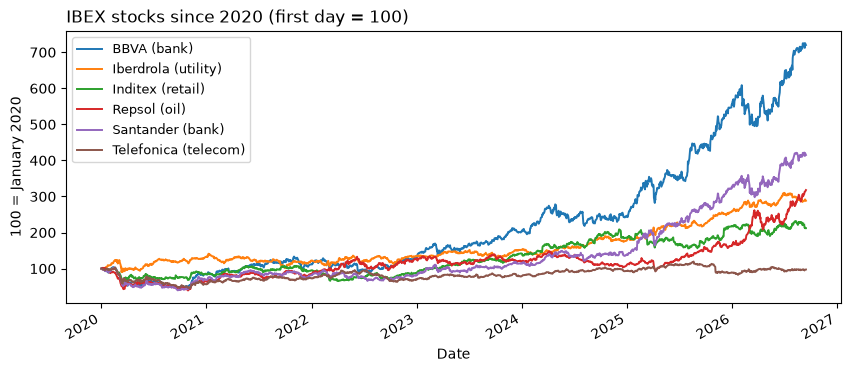

In [13]:
# Divide by the first price so they all start at 100 and I can compare them
normalised = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4))
normalised.plot(ax=ax, linewidth=1.4)
ax.set_title("IBEX stocks since 2020 (first day = 100)", loc="left")
ax.set_ylabel("100 = January 2020")
ax.legend(fontsize=9)
plt.show()

In [14]:
# FRED gives you any series as a CSV, no API key needed
def fred(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    table = pd.read_csv(url, parse_dates=["observation_date"], index_col="observation_date")
    return table[series_id]


euribor = fred("IR3TIB01EZM156N")
spread = fred("IRLTLT01ESM156N") - fred("IRLTLT01DEM156N")

# EUR/BRL and Brent come from Yahoo, same as the stocks
fx_oil = yf.download(["EURBRL=X", "BZ=F"], start="2020-01-01", auto_adjust=True, progress=False)["Close"]

print("Euribor 3m      :", euribor.index.min().date(), "to", euribor.index.max().date())
print("ES-DE spread    :", spread.dropna().index.min().date(), "to", spread.dropna().index.max().date())
print("EUR/BRL, Brent  :", fx_oil.index.min().date(), "to", fx_oil.index.max().date())

Euribor 3m      : 1994-01-01 to 2026-01-01
ES-DE spread    : 1980-01-01 to 2026-06-01
EUR/BRL, Brent  : 2020-01-01 to 2026-09-14


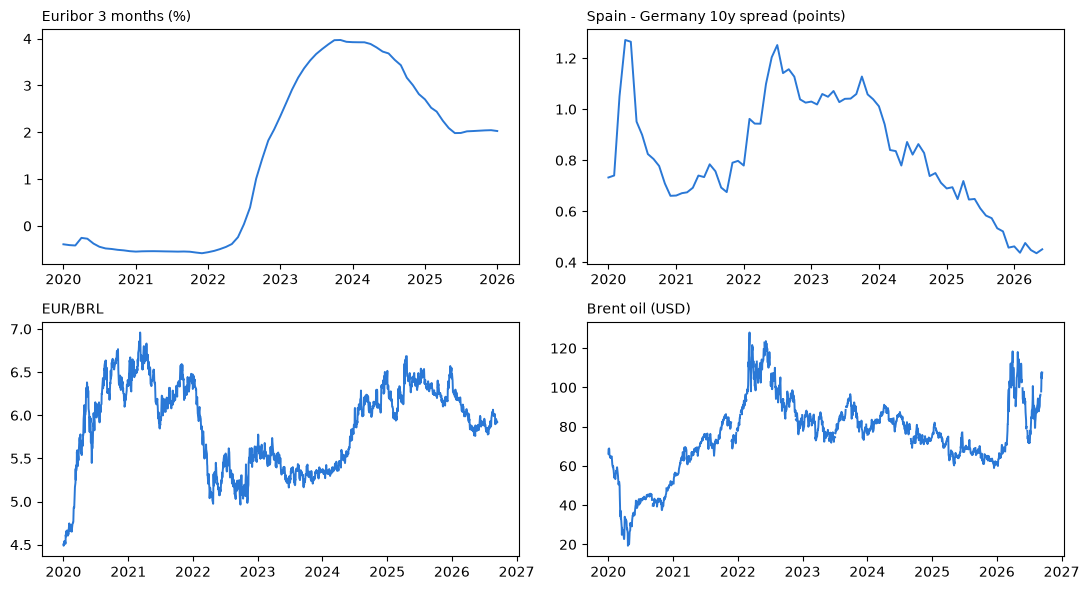

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

panels = [
    (euribor["2020":], "Euribor 3 months (%)", axes[0, 0]),
    (spread["2020":], "Spain - Germany 10y spread (points)", axes[0, 1]),
    (fx_oil["EURBRL=X"], "EUR/BRL", axes[1, 0]),
    (fx_oil["BZ=F"], "Brent oil (USD)", axes[1, 1]),
]

for data, title, ax in panels:
    ax.plot(data.index, data.values, color="#2a78d6", linewidth=1.4)
    ax.set_title(title, loc="left", fontsize=10)

fig.tight_layout()
plt.show()

The plots show why these are worth testing. The six stocks clearly do **not** move
together, which is what my project needs. And the four variables move a lot over the
period: Euribor goes from below zero to almost 4%, and Brent collapses in 2020 and spikes
in 2022. Those are exactly the moments when I would expect banks, Repsol and Inditex to
separate from each other.

Next step is to check whether they really do separate the stocks, by looking at each
stock's return against each variable.

## Submitting the solutions

Form for submitting: https://courses.datatalks.club/sma-zoomcamp-2026/homework/hw01

---
## Leaderboard

Leaderboard link: https://courses.datatalks.club/sma-zoomcamp-2026/leaderboard

---